In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [3]:
results = pd.read_csv("results_no_reg.csv")
for mu in results["mu"].unique():
    results_mu = results.loc[results["mu"] == mu]
    table = pd.pivot_table(results_mu, values="loss_successes_percent", 
                           index=["x0"],
                           columns=["T"],
                           aggfunc="mean")
    
    table.to_csv(f"grid_no_reg_results_mu{mu}.csv")
    
    sns.heatmap(table)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn')
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results_no_reg.csv'

In [4]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}


results = pd.read_csv("results_reg_derivative_unstable_fp_eps1.csv")
dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)


results["T-x0"] = results["T"].astype(str) + "-" + results["x0"].astype(str)

for settings in results["T-x0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table, vmin=0, vmax=1.0)
        plt.title(f"T-theta0 {settings}, {regularization_names[regularization]}")
        plt.savefig(f"{dirname}/van_der_pol_results_{regularization}_settingsT-theta0_{settings}.png")
        plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results_reg_derivative_unstable_fp_eps1.csv'

Index(['Unnamed: 0', '(x0, x_t0)', 'converged to', 'closest fp', 'stability',
       'success', 'x0', 'x_t0'],
      dtype='object')


/tmp/ipykernel_198940/1714343647.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  table_no_reg["stability"].fillna(value="not a fp", inplace=True)
/tmp/ipykernel_198940/1714343647.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not a fp' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table_no_reg["stability"].fillna(value="not a fp", inplace=True)


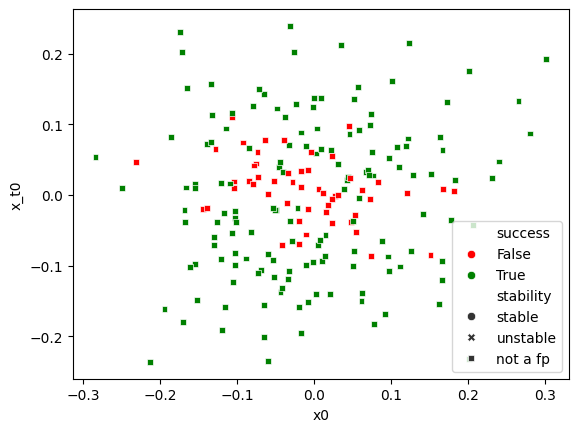

'\ntable_reg = pd.read_csv("convergence_points_reg.csv")\ntable_reg["stability with reg"].fillna(value="not a fp", inplace=True)\ntable_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"\ntable_reg["x0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[0])\ntable_reg["x_t0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[1])\ntable_reg["xT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[0])\ntable_reg["yT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[1])\n\nplt.figure()\nsns.scatterplot(data=table_reg, x="x0", y="x_t0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])\nplt.show()\n'

In [20]:
table_no_reg = pd.read_csv("convergence_points.csv")
table_no_reg["x0"] = table_no_reg["(x0, x_t0)"].apply(lambda row: eval(row)[0])
table_no_reg["x_t0"] = table_no_reg["(x0, x_t0)"].apply(lambda row: eval(row)[1])
table_no_reg["stability"].fillna(value="not a fp", inplace=True)

print(table_no_reg.columns)
colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=table_no_reg, x="x0", y="x_t0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()
"""
table_reg = pd.read_csv("convergence_points_reg.csv")
table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
table_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"
table_reg["x0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[0])
table_reg["x_t0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[1])
table_reg["xT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[0])
table_reg["yT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[1])

plt.figure()
sns.scatterplot(data=table_reg, x="x0", y="x_t0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()
"""